# Random Forest & Logistic Regression Experiments

**Overview**

This notebook examines the performance of two models (Random Forest and Logistic Regression) under different strategies for handling class imbalance.  The following approaches are considered:

- Baseline (no handling)
- Class weight 
- SMOTE 
- SMOTEENN 

**To ensure a fair and consistent comparison, the following setup is maintained across all experiments:**

- All models share the same preprocessing pipeline to prevent data leakage.
- Stratified K-Fold cross-validation is applied to preserve class distribution across folds.
- A unified evaluation function is used to compute all metrics consistently.
- All results are stored in a shared table for cross-model and cross-strategy comparison.



## Setup

In [16]:
# Add project root to system path so we can import from src/
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent.parent / "bank-deposit-prediction"
sys.path.append(str(PROJECT_ROOT))

# Standard libraries
import pandas as pd

# Modeling
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Imbalanced learning tools
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Shared project modules
from src.shared import get_cv, get_preprocessing_steps
from src.evaluation import evaluate_model, save_results

## Data Loading
The dataset is loaded and split into features (X) and target variable (y).  
The target is encoded as binary values:
- 1 → "yes"
- 0 → "no"

In [17]:
data_path = PROJECT_ROOT / "data" / "raw" / "bank2.csv"

df = pd.read_csv(data_path, sep=';')

y = df['y'].map({'yes': 1, 'no': 0})
X = df.drop(columns=['y'])

## Shared components
The following components are used throughout the experiments:
- A centralized preprocessing pipeline to prevent data leakage
- Stratified K-Fold cross-validation, ensuring a fair evaluation

In [18]:
# Get shared cross-validation strategy
cv = get_cv()

## Random Forest



### Baseline Random Forest

We begin with the baseline model without applying any imbalance handling.

In [19]:
# Store experiment results
all_results = []

# Baseline Random Forest (no imbalance handling)
baseline_rf_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model using cross-validation
result_rf_baseline = evaluate_model(
    "RandomForest",
    "Baseline",
    baseline_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_baseline)

result_rf_baseline

{'Model': 'RandomForest',
 'Strategy': 'Baseline',
 'Accuracy': '0.8894 ± 0.0040',
 'Precision': '0.6156 ± 0.1284',
 'Recall': '0.1266 ± 0.0174',
 'F1': '0.2084 ± 0.0244',
 'PR-AUC': '0.3515 ± 0.0266',
 'ROC-AUC': '0.7351 ± 0.0182'}

### Class Weight Random Forest

In this experiment, class weights are introduced to give more importance to the minority class during training.

In [20]:
# Class weight Random Forest
cw_rf_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
    ]
)

# Evaluate model using cross-validation
result_rf_cw = evaluate_model(
    "RandomForest",
    "ClassWeight",
    cw_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_cw)

result_rf_cw

{'Model': 'RandomForest',
 'Strategy': 'ClassWeight',
 'Accuracy': '0.8905 ± 0.0050',
 'Precision': '0.6311 ± 0.1390',
 'Recall': '0.1151 ± 0.0343',
 'F1': '0.1936 ± 0.0555',
 'PR-AUC': '0.3437 ± 0.0402',
 'ROC-AUC': '0.7329 ± 0.0261'}

### SMOTE Random Forest

In this experiment, SMOTE is applied to oversample the minority class and improve model sensitivity.

In [21]:
# SMOTE Random Forest
smote_rf_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model
result_rf_smote = evaluate_model(
    "RandomForest",
    "SMOTE",
    smote_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_smote)

result_rf_smote

{'Model': 'RandomForest',
 'Strategy': 'SMOTE',
 'Accuracy': '0.8856 ± 0.0059',
 'Precision': '0.5179 ± 0.0965',
 'Recall': '0.1535 ± 0.0315',
 'F1': '0.2354 ± 0.0439',
 'PR-AUC': '0.3215 ± 0.0377',
 'ROC-AUC': '0.7259 ± 0.0223'}

### SMOTEENN Random Forest

In this experiment, a hybrid approach (SMOTEENN) is applied to both oversample the minority class and clean noisy samples.

In [101]:
# SMOTEENN Random Forest
smoteenn_rf_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smoteenn', SMOTEENN(random_state=42)),
        ('model', RandomForestClassifier(random_state=42))
    ]
)

# Evaluate model
result_rf_smoteenn = evaluate_model(
    "RandomForest",
    "SMOTEENN",
    smoteenn_rf_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_rf_smoteenn)

result_rf_smoteenn

{'Model': 'RandomForest',
 'Strategy': 'SMOTEENN',
 'Accuracy': '0.8268 ± 0.0072',
 'Precision': '0.3145 ± 0.0123',
 'Recall': '0.4242 ± 0.0192',
 'F1': '0.3609 ± 0.0101',
 'PR-AUC': '0.3048 ± 0.0307',
 'ROC-AUC': '0.7205 ± 0.0270'}

## Logistic Regression

### Baseline Logistic Regression

We begin with the baseline model without applying any imbalance handling.

In [8]:
# Baseline Logistic Regression
baseline_lr_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', LogisticRegression(max_iter=5000, random_state=42))
    ]
)

# Evaluate model
result_lr_baseline = evaluate_model(
    "LogisticRegression",
    "Baseline",
    baseline_lr_pipeline,
    X,
    y,
    cv
)

# Save and display results
all_results.append(result_lr_baseline)

result_lr_baseline

{'Model': 'LogisticRegression',
 'Strategy': 'Baseline',
 'Accuracy': np.float64(0.8923),
 'Precision': np.float64(0.6605),
 'Recall': np.float64(0.1439),
 'F1': np.float64(0.2342),
 'ROC-AUC': np.float64(0.7247),
 'PR-AUC': np.float64(0.3482)}

### Class Weight (Imbalance Handling)

- Adjusts the model to give more importance to the minority class
- Helps improve recall for the positive class without changing the data

In [9]:
# Logistic Regression with class weight

lr_cw_pipeline = Pipeline(
    get_preprocessing_steps() + [
        ('model', LogisticRegression(
            class_weight='balanced',
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_cw = evaluate_model(
    "LogisticRegression",
    "ClassWeight",
    lr_cw_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_cw)

# Display results
result_lr_cw

{'Model': 'LogisticRegression',
 'Strategy': 'ClassWeight',
 'Accuracy': np.float64(0.7125),
 'Precision': np.float64(0.2188),
 'Recall': np.float64(0.5815),
 'F1': np.float64(0.3176),
 'ROC-AUC': np.float64(0.7238),
 'PR-AUC': np.float64(0.3407)}

### SMOTE Logistic Regression

SMOTE is applied to oversample the minority class and improve the model’s ability to detect positive cases.

In [10]:
# SMOTE Logistic Regression
lr_smote_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_smote = evaluate_model(
    "LogisticRegression",
    "SMOTE",
    lr_smote_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_smote)

# Display results
result_lr_smote

{'Model': 'LogisticRegression',
 'Strategy': 'SMOTE',
 'Accuracy': np.float64(0.7211),
 'Precision': np.float64(0.2252),
 'Recall': np.float64(0.5815),
 'F1': np.float64(0.3244),
 'ROC-AUC': np.float64(0.7166),
 'PR-AUC': np.float64(0.335)}

### SMOTEENN Logistic Regression

A hybrid approach combining SMOTE and ENN is applied to both oversample the minority class and remove noisy observations.

In [11]:
# SMOTEENN Logistic Regression
lr_smoteenn_pipeline = ImbPipeline(
    get_preprocessing_steps() + [
        ('smoteenn', SMOTEENN(random_state=42)),
        ('model', LogisticRegression(
            max_iter=5000,
            random_state=42
        ))
    ]
)

# Evaluate model
result_lr_smoteenn = evaluate_model(
    "LogisticRegression",
    "SMOTEENN",
    lr_smoteenn_pipeline,
    X,
    y,
    cv
)

# Save results
all_results.append(result_lr_smoteenn)

# Display results
result_lr_smoteenn

{'Model': 'LogisticRegression',
 'Strategy': 'SMOTEENN',
 'Accuracy': np.float64(0.5417),
 'Precision': np.float64(0.168),
 'Recall': np.float64(0.7524),
 'F1': np.float64(0.2745),
 'ROC-AUC': np.float64(0.7205),
 'PR-AUC': np.float64(0.3284)}

In [12]:
# Convert results to DataFrame
results_df = pd.DataFrame(all_results)

# Save to shared results table
save_results(results_df)

In [13]:
results_path = PROJECT_ROOT / "results" / "experiment_results.csv"
results = pd.read_csv(results_path)

results

,Model,Strategy,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,XGBoost,Baseline,0.8830,0.4765,0.1784,0.2590,0.7020,0.3037
1,XGBoost,ClassWeight,0.8498,0.3300,0.2936,0.3099,0.6806,0.2791
2,XGBoost,SMOTE,0.8834,0.4829,0.1765,0.2567,0.7172,0.3178
3,XGBoost,SMOTEENN,0.8290,0.3266,0.4549,0.3800,0.7270,0.3323
4,RandomForest,Baseline,0.8885,0.5940,0.1209,0.1989,0.7333,0.3482
5,RandomForest,ClassWeight,0.8910,0.6479,0.1151,0.1947,0.7384,0.3418
6,RandomForest,SMOTE,0.8848,0.5003,0.1516,0.2320,0.7252,0.3234
7,RandomForest,SMOTEENN,0.8275,0.3171,0.4281,0.3639,0.7207,0.3064
8,LogisticRegression,Baseline,0.8923,0.6605,0.1439,0.2342,0.7247,0.3482
9,LogisticRegression,ClassWeight,0.7125,0.2188,0.5815,0.3176,0.7238,0.3407


# Evaluation & Analysis

## Setup

In [ ]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.pipeline import Pipeline as ImbPipeline
from src.shared import drop_columns, transform_pdays

final_model=smoteenn_rf_pipeline
final_model.fit(X, y)

,steps,"[('drop_columns', ...), ('pdays_transform', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function dro...00178606D2D40>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


## Feature Importance

In [116]:
preprocessor = final_model.named_steps['preprocessor']
feature_names = preprocessor.get_feature_names_out()

In [117]:
rf_model = final_model.named_steps['model'] 

In [118]:
rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

rf_importance.head(10)

num__balance             0.058103
cat__contact_cellular    0.052924
cat__contact_unknown     0.049877
num__age                 0.046487
num__campaign            0.044477
cat__marital_married     0.034336
cat__loan_no             0.029794
cat__job_blue-collar     0.029696
cat__housing_yes         0.025835
cat__housing_no          0.025816
dtype: float64

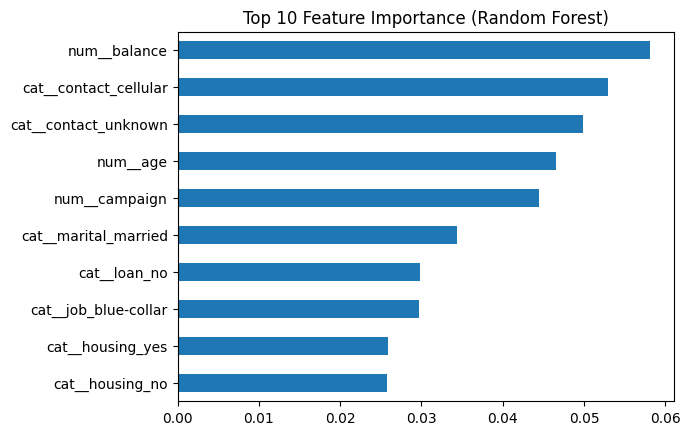

In [119]:
rf_importance.head(10).sort_values().plot(kind='barh')
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

## SHAP Analysis

In [ ]:
print("⏳ Training model for SHAP audit...")

# Apply preprocessing 
X_temp = final_model.named_steps['drop_columns'].transform(X)
X_temp = final_model.named_steps['pdays_transform'].transform(X_temp)

X_transformed = final_model.named_steps['preprocessor'].transform(X_temp)

# Convert sparse → dense
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()
else:
    X_transformed = X_transformed

#  Get feature names
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()

#  Convert to DataFrame
X_df = pd.DataFrame(X_transformed, columns=feature_names)

#  Extract model
rf_model = final_model.named_steps['model']

#  SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_df)

# Handle both possible formats
if isinstance(shap_values, list):
    # Old format
    final_shap = shap_values[1]
else:
    # New format (3D array)
    final_shap = shap_values[:, :, 1]
    
#  Plots
shap.summary_plot(final_shap, X_df)
shap.summary_plot(final_shap, X_df, plot_type="bar")